In [1]:
!which python
!pip freeze > requirements.txt

/home/sa1/Documents/gitReps/pythonQuickAndDirty/venv/bin/python


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")

# input_data, output_data

# Visualisation

In [ ]:
input_data.nunique()
# input_data.info()
input_data.head()
input_data = input_data.loc[:, input_data.nunique() > 1]
# input_21 is degrees and should be converted to radians
# input_data.iloc[:, 21] = np.radians(input_data.iloc[:, 21])
# input_data.describe()
#input_20 is initial hair length
# input_14 is elevation angle is in degrees
# High 1 10
# Second High 11 3 9 2 4 6
# Third High 18 19 
input_data.nunique()
# Drop columns with only one unique value
input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()
# input_data.head()
# Number of rows in input_data and output_data
# len(input_data), len(output_data)

,input_1,input_2,input_3,input_4,input_5,input_6,input_7,input_8,input_9,input_10,input_11,input_14,input_18,input_19,input_20,input_21,input_22
0,C01,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,62.311333,-12.950,-1.136,930.932365,326.904678,21.103807
1,C01,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,55.742061,-12.239,-4.382,1082.927137,153.042818,13.931269
2,C01,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,67.942716,-10.024,8.277,984.849277,38.213696,18.031709
3,C01,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,45.419135,-11.168,6.654,983.234347,357.832140,11.502451
4,C01,79,83,57,82,189,233,290-360-260,366-388-364,V-type,15,61.599897,-12.991,0.487,704.864190,204.853589,20.680040


# Preprocessing

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_input(
    input_data,
    encodingHigh=0,
    categoricalEncodingHighType="one-hot",
    encodingMed=0,
    categoricalEncodingMedType="one-hot",
    encodingLow=0,
    categoricalEncodingLowType="one-hot",
    convertToRadians=0
):
    df = input_data.copy()

    # If nothing is enabled, return unchanged
    if (
        encodingHigh == 0 and
        encodingMed == 0 and
        encodingLow == 0 and
        convertToRadians == 0
    ):
        return df

    # Helper function
    def encode_columns(df, cols, encoding_type):
        cols = [col for col in cols if col in df.columns]

        if len(cols) == 0:
            return df

        if encoding_type is None:
            encoding_type = "one-hot"

        encoding_type = encoding_type.lower()

        if encoding_type == "one-hot":
            df = pd.get_dummies(df, columns=cols)

        elif encoding_type == "label":
            le = LabelEncoder()
            for col in cols:
                df[col] = le.fit_transform(df[col].astype(str))

        return df

    # High group
    if encodingHigh != 0:
        high_cols = ["input_10"]
        df = encode_columns(df, high_cols, categoricalEncodingHighType)

    # Medium group
    if encodingMed != 0:
        med_cols = [
            "input_2", "input_3", "input_4",
            "input_6", "input_8","input_9", "input_11",
            "input_10"
        ]
        df = encode_columns(df, med_cols, categoricalEncodingMedType)

    # Low group
    if encodingLow != 0:
        low_cols = ["input_18", "input_19"]
        df = encode_columns(df, low_cols, categoricalEncodingLowType)

    # Convert angles to radians
    if convertToRadians != 0:
        for col in ["input_14", "input_21"]:
            if col in df.columns:
                df[col] = np.deg2rad(df[col])

    return df

# Train Test Split

In [34]:
import numpy as np

def trainTestSplit(processedInput, output, Train=10, Test=3, seed=42):
    # Unique values of input_1
    unique_vals = processedInput["input_1"].unique()

    # Check count
    if len(unique_vals) != Train + Test:
        raise ValueError(
            f"Found {len(unique_vals)} unique values in input_1, "
            f"but Train + Test = {Train + Test}"
        )

    # Shuffle with seed
    rng = np.random.RandomState(seed)
    shuffled_vals = unique_vals.copy()
    rng.shuffle(shuffled_vals)

    # Split
    TrainVals = shuffled_vals[:Train]
    TestVals = shuffled_vals[Train:]

    # Create train and test sets
    input_train = processedInput[processedInput["input_1"].isin(TrainVals)].copy()
    input_test = processedInput[processedInput["input_1"].isin(TestVals)].copy()
    output_train = output[processedInput["input_1"].isin(TrainVals)].copy()
    output_test = output[processedInput["input_1"].isin(TestVals)].copy()

    # Drop input_1 after splitting
    input_train = input_train.drop(columns=["input_1"])
    input_test = input_test.drop(columns=["input_1"])

    return input_train, input_test,output_train,output_test, TrainVals, TestVals


input_data.nunique()
# Drop columns with only one unique value
input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()

processed_input = preprocess_input(input_data, encodingHigh=1, categoricalEncodingHighType="one-hot", encodingMed=1, categoricalEncodingMedType="one-hot", encodingLow=1, categoricalEncodingLowType="one-hot", convertToRadians=1)
input_train, input_test,output_train,output_test, TrainVals, TestVals = trainTestSplit(processedInput=processed_input, output=output_data, Train=10, Test=3, seed=42)
input_train.head()


,input_5,input_7,input_14,input_20,input_21,input_22,input_10_S-type,input_10_V-type,input_2_73,input_2_79,...,input_19_6.979,input_19_7.303,input_19_7.628,input_19_7.952,input_19_8.277,input_19_8.602,input_19_8.926,input_19_9.251,input_19_9.575,input_19_9.9
0,82,233,1.087538,930.932365,5.705563,21.103807,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,82,233,0.972883,1082.927137,2.671101,13.931269,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,82,233,1.185824,984.849277,0.666955,18.031709,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
3,82,233,0.792713,983.234347,6.245349,11.502451,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,82,233,1.075121,704.864190,3.575370,20.680040,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


# TabPFN
Does not work. Licensed tool. 

In [ ]:
# from tabpfn import TabPFNClassifier, TabPFNRegressor

# # clf = TabPFNClassifier()
# # clf.fit(input_train, output_data)  # downloads checkpoint on first use
# # predictions = clf.predict(input_test)

# reg = TabPFNRegressor()
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# predictions = reg.predict(input_test)

# Tree Models Initialisation

In [35]:
from sklearn.model_selection import train_test_split # Function to split data into training and testing sets
import numpy as np


from xgboost import XGBRegressor

def train_xgboost(X_train, y_train):
    model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    verbosity=2
)

    model.fit(X_train, y_train, verbose=True)
    return model

from lightgbm import LGBMRegressor
def train_lightgbm(X_train, y_train):
    model = LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    return model

from catboost import CatBoostRegressor
def train_catboost(X_train, y_train, categorical_columns=None):
    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=10
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_columns
    )

    return model

In [30]:
output_data.head()

,output_1,output_2,output_3
0,1.0,1.0,101.212365
1,1.0,7.0,120.877137
2,1.0,3.0,10.012277
3,1.0,1.0,42.109347
4,1.0,6.0,42.620190


# Training on Output_1

In [43]:
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_1"])
lgb_model = train_lightgbm(input_train, output_train["output_1"])
cat_model = train_catboost(input_train, output_train["output_1"])

[14:39:09] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (32723, 140, 4581220).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,001136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1288
[LightGBM] [Info] Number of data points in the train set: 32723, number of used features: 137
[LightGBM] [Info] Start training from score 0,411973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
0:

# Testing

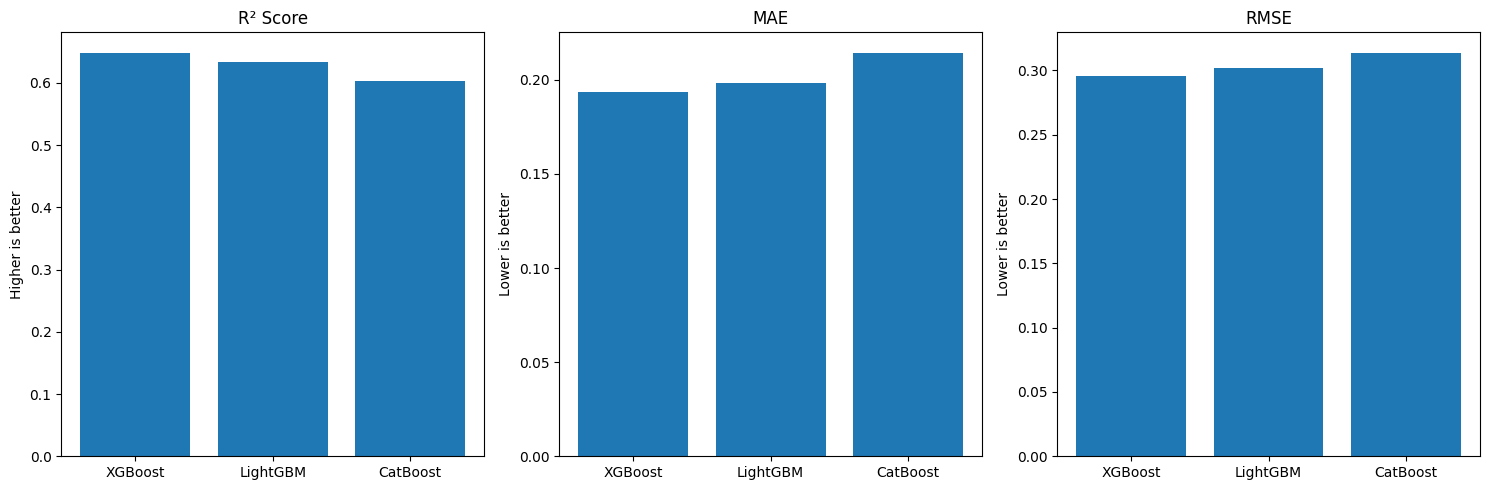

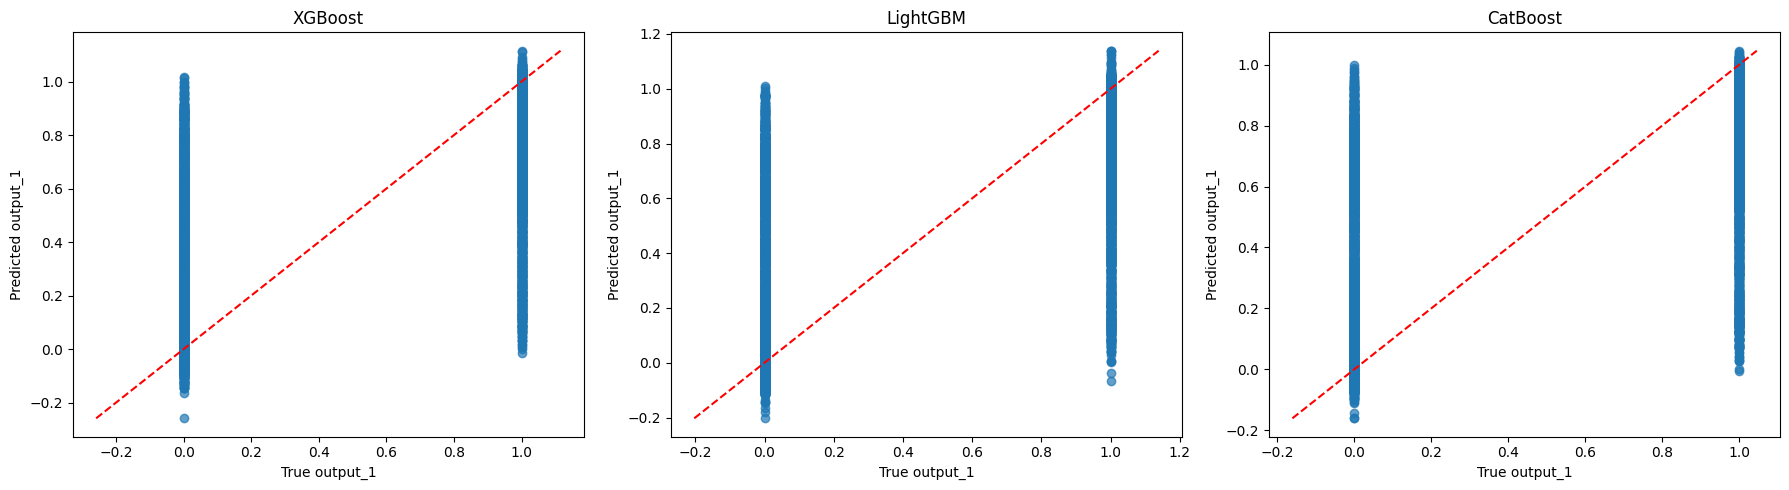

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_1"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_1")
    ax.set_ylabel("Predicted output_1")

plt.tight_layout()
plt.show()

# Training Output 2

In [53]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_2"])
lgb_model = train_lightgbm(input_train, output_train["output_2"])
cat_model = train_catboost(input_train, output_train["output_2"])

[14:40:40] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (32723, 140, 4581220).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,001583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1288
[LightGBM] [Info] Number of data points in the train set: 32723, number of used features: 137
[LightGBM] [Info] Start training from score 2,971060
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

# Testing Output 2

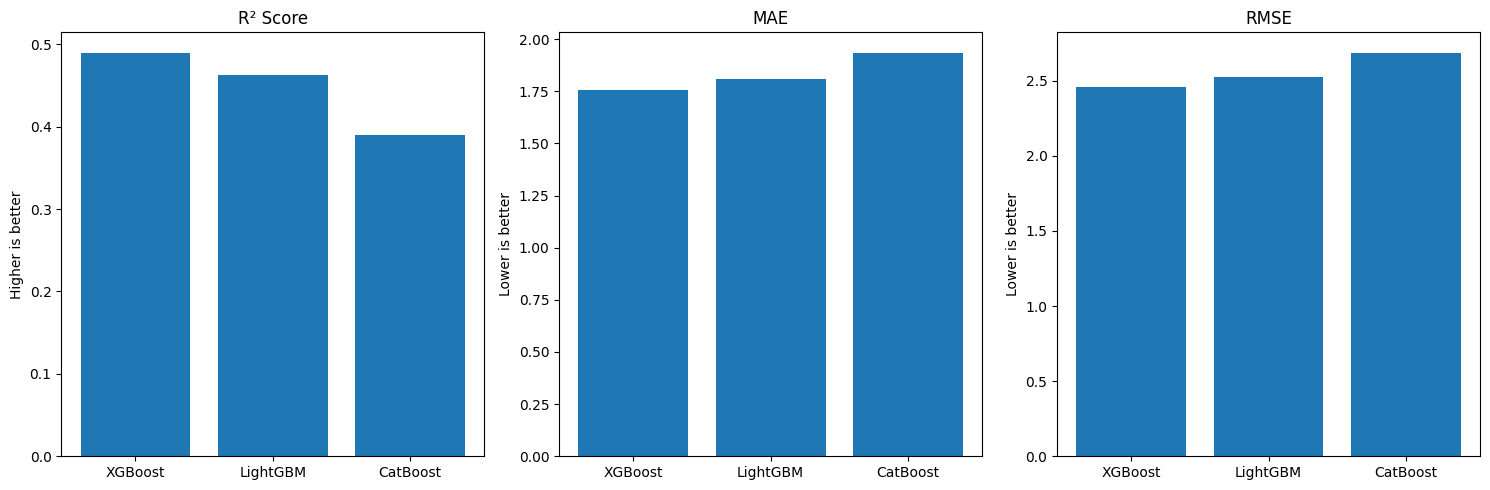

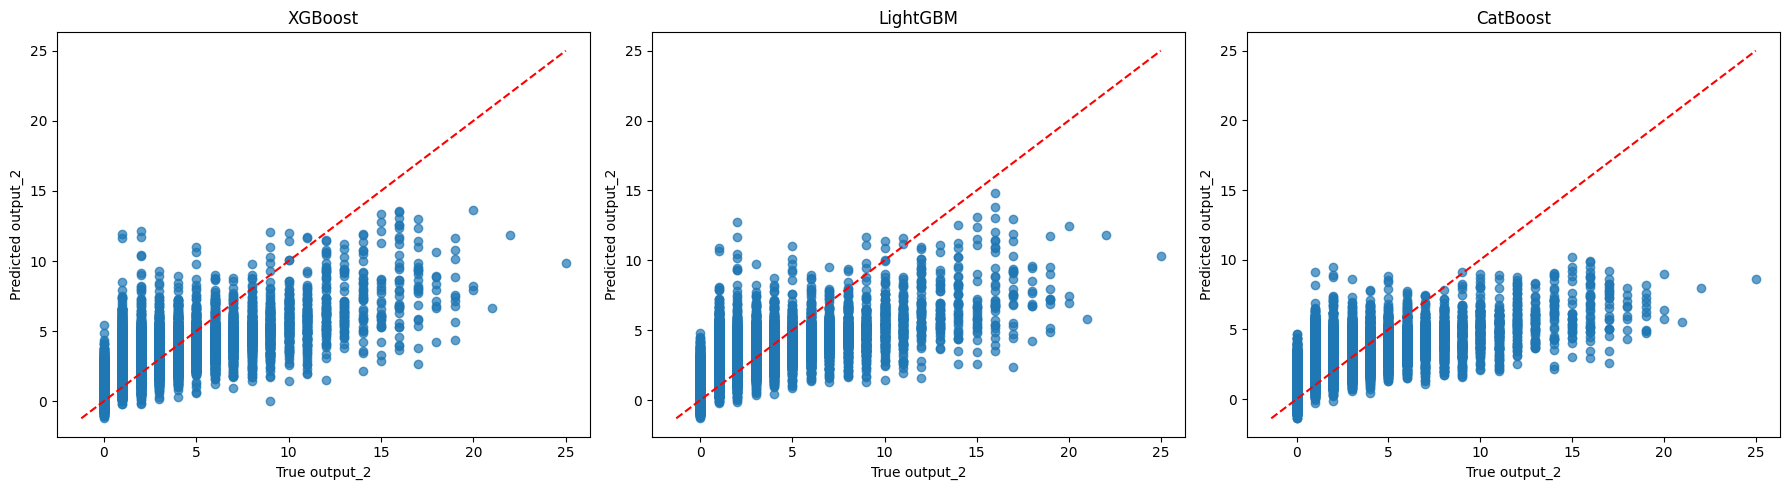

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_2"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_2")
    ax.set_ylabel("Predicted output_2")

plt.tight_layout()
plt.show()

# Training Output 3

In [51]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_3"])
lgb_model = train_lightgbm(input_train, output_train["output_3"])
cat_model = train_catboost(input_train, output_train["output_3"])

[14:40:25] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (32723, 140, 4581220).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,001899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1288
[LightGBM] [Info] Number of data points in the train set: 32723, number of used features: 137
[LightGBM] [Info] Start training from score 211,434139
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Testing Output 3

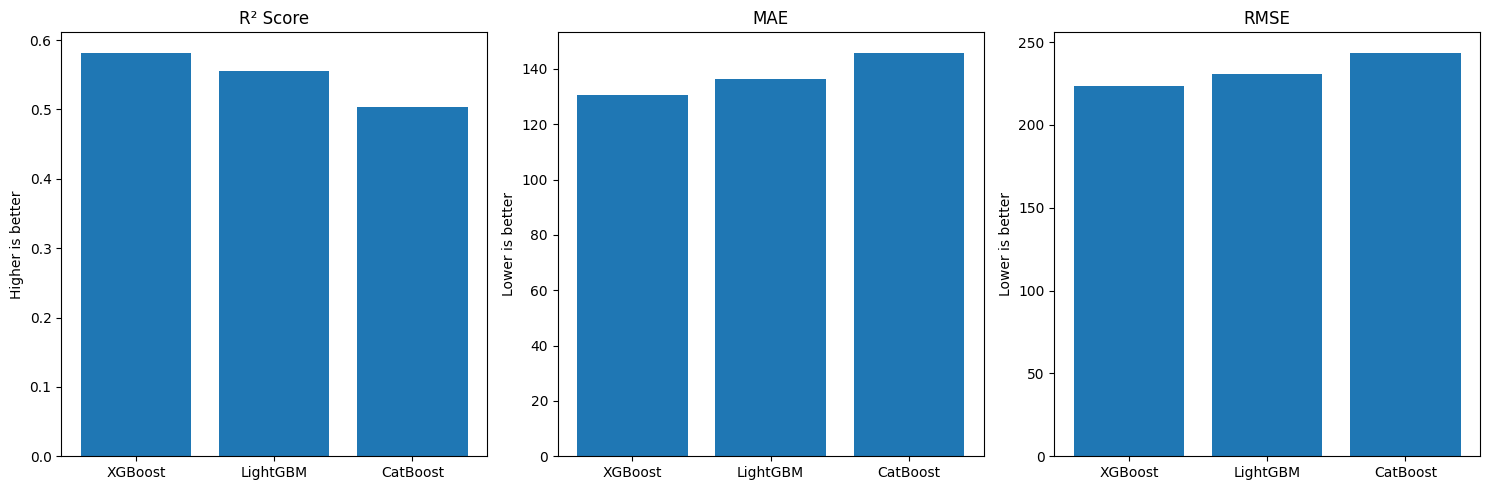

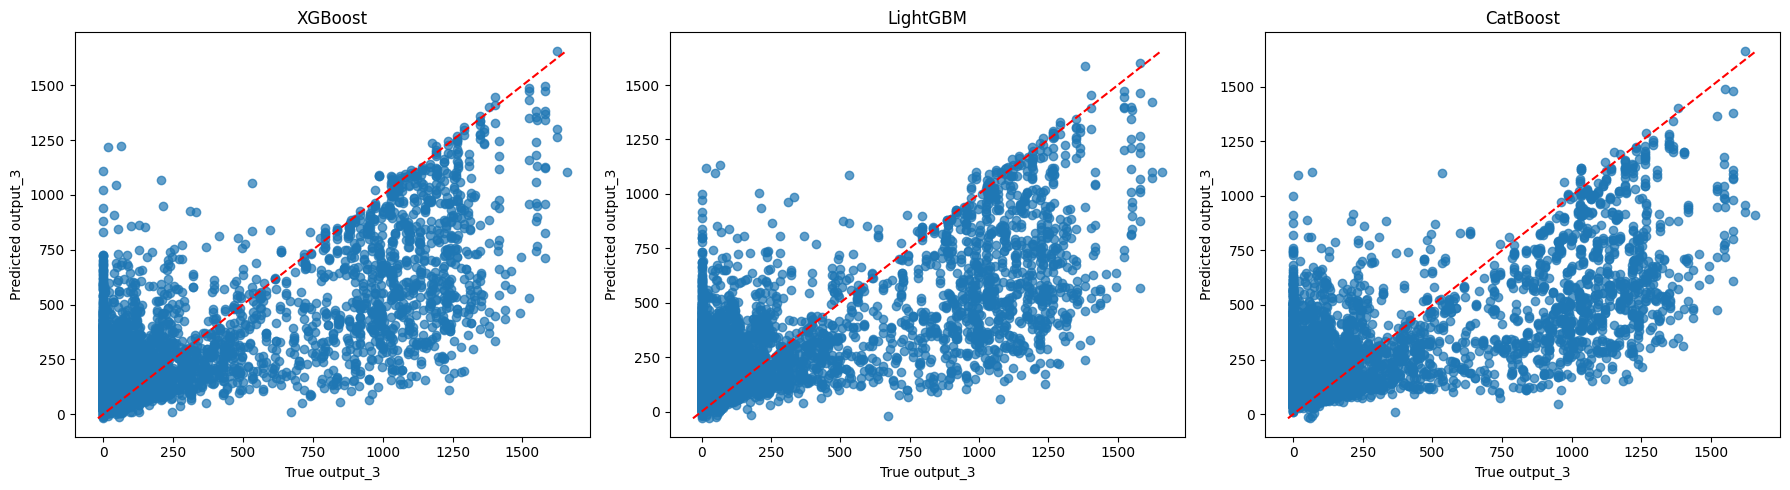

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_3"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_3")
    ax.set_ylabel("Predicted output_3")

plt.tight_layout()
plt.show()